<a href="https://colab.research.google.com/github/OmkarRameshJadhav108/-OpenEdHub-Open-Source-Online-Learning-Platform/blob/main/stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Google_Stock_Price.csv to Google_Stock_Price.csv


In [6]:
df = pd.read_csv("Google_Stock_Price.csv", thousands=',')

In [7]:
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)

In [8]:
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]


In [9]:
scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)


In [10]:
def create_dataset(dataset, time_step=60):
    X, y = [], []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [11]:
X_train, y_train = create_dataset(train_scaled)

In [12]:
total_data = np.concatenate((train_scaled[-60:], test_scaled), axis=0)

X_test, y_test = create_dataset(total_data)

In [13]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [14]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0547
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0039
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0018
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0015
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0014
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0013
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0012
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0011
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.5798e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0012
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.6900e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.7154e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.8463e-04
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - l

In [17]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 8.3085e-04
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 7.9229e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.9035e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 8.0959e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 7.1103e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 8.1912e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.6978e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.2228e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.9099e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.6894e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.5812e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.9814e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 6.7957e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 8.1712e-04
Epoch 15/20
30/

In [18]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.8171e-04
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.0183e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.3018e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.7825e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.5659e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.1771e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.5105e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 6.5837e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 7.6602e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 6.1417e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 5.6544e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.5380e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.4717e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 5.3288e-04
Epoch 15/20
30/

In [19]:
predicted = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [20]:
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

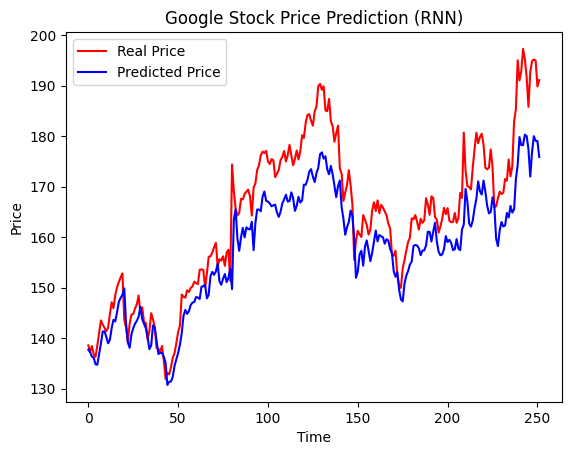

In [21]:
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()